# Digital Typhoon Dataset Wrapper Test

In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

Adding /home/ando to sys.path


## Test Dataset

In [19]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/digital_typhoon.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

In [20]:
display(ds_cfg)

{'defaults': ['base_dataset'], 'dataset_type': 'digital_typhoon', 'task': 'regression', 'dataset_name': 'digital_typhoon', 'num_classes': 1, 'num_channels': 3, 'data_path': '${oc.env:DATASETS_DIR}/DigitalTyphoon', 'image_resolution': 224, 'multilabel': False, 'wavelengths_mean_nm': [1111, 1111, 1111], 'wavelengths_mean_microns': [1.111, 1.111, 1.111], 'wavelengths_sigma_nm': [25, 25, 25]}

In [21]:
import random
i = random.randint(0, len(train_ds))
sample, label = train_ds[i]
sample.shape, label

(torch.Size([3, 224, 224]), tensor([-1.1229]))

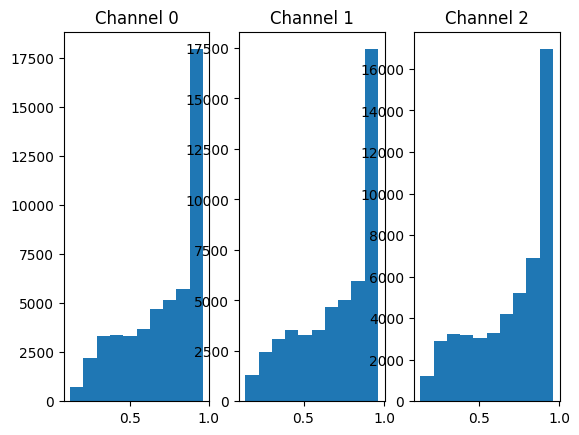

In [22]:
import matplotlib.pyplot as plt
# display the histogram of each channel
i = random.randint(0, len(train_ds))
sample, label = train_ds[i]
img = sample.numpy().transpose(1, 2, 0)
for i in range(img.shape[2]):
    plt.subplot(1, img.shape[2], i+1)
    plt.hist(img[:,:,i].flatten())
    plt.title(f'Channel {i}')
plt.show()


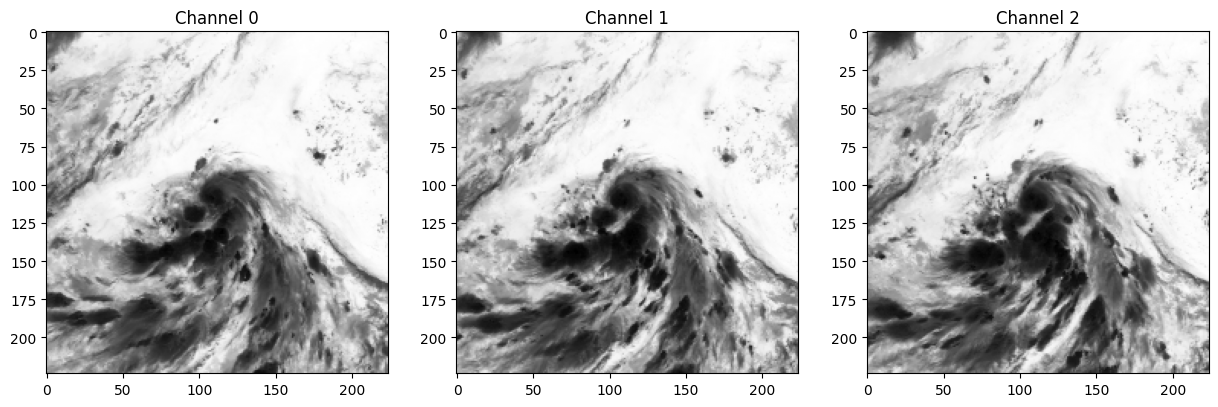

In [23]:



plt.figure(figsize=(15, 5))  # Increase the figure size for larger images
for i in range(img.shape[2]):
    plt.subplot(1, img.shape[2], i+1)
    plt.imshow(img[:,:,i], cmap='gray')
    plt.title(f'Channel {i}')
plt.show()


# plt.imshow(img)
# plt.show()

